### Count Velocity Obs

In [6]:
import xarray as xr

filepath_2012 = '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2012_ADCP_v2.nc'
filepath_2013 = '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2013_ADCP.nc'

ds_adcp = xr.concat([xr.open_dataset(filepath_2012), xr.open_dataset(filepath_2013)], dim='iPROF')

filepath_2012 = '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2012_CUR_v2.nc'
filepath_2013 = '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2013_CUR.nc'

ds_cur = xr.concat([xr.open_dataset(filepath_2012), xr.open_dataset(filepath_2013)], dim='iPROF')

/tmp/ipykernel_1653893/2532352644.py:6: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_adcp = xr.concat([xr.open_dataset(filepath_2012), xr.open_dataset(filepath_2013)], dim='iPROF')
/tmp/ipykernel_1653893/2532352644.py:11: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_cur = xr.concat([xr.open_dataset(file

In [8]:
total_adcp_U = ds_adcp['prof_U'].count()
total_adcp_V = ds_adcp['prof_V'].count()
total_cur_U = ds_cur['prof_U'].count()
total_cur_V = ds_cur['prof_V'].count()

total = total_adcp_U + total_adcp_V + total_cur_U + total_cur_V

percent_cur = (total_cur_U + total_cur_V) / total * 100
percent_adcp = (total_adcp_U + total_adcp_V) / total * 100
print(f"percent ADCP profiles: {total_adcp_U + total_adcp_V} ({percent_adcp:.2f}%)")
print(f"percent CUR profiles: {total_cur_U + total_cur_V} ({percent_cur:.2f}%)")

percent ADCP profiles: <xarray.DataArray ()> Size: 8B
array(8724640) (83.78%)
percent CUR profiles: <xarray.DataArray ()> Size: 8B
array(1688640) (16.22%)


### Count SSH Obs

In [1]:
## Read in ITER 0 Diagnostics 
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np
import xarray as xr

## it doesnt matter what this is, we just want the grid in ds format
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'

prefix = ['diag_state']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=72,prefix=prefix,ref_date='2012-09-01',delta_t=1200)
ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)

In [16]:
import numpy as np
import pandas as pd

# File paths for both years
rads_ja_2012 = '/data/SO6/TPOSE/constraints/rads/rads_ja_tpose6_QC_2012'
rads_c2_2012 = '/data/SO6/TPOSE/constraints/rads/rads_c2_tpose6_QC_2012'
rads_ja_2013 = '/data/SO6/TPOSE/constraints/rads/rads_ja_tpose6_QC_2013'
rads_c2_2013 = '/data/SO6/TPOSE/constraints/rads/rads_c2_tpose6_QC_2013'

def load_rads(filename, nx, ny, nt):
    with open(filename, 'rb') as f:
        data = np.fromfile(f, dtype='>f4')
    data = data.reshape((nx, ny, nt), order='F').transpose(1, 0, 2).astype(float)
    data[data == -9999.0] = np.nan
    return data / 100  # cm to m

nx, ny = len(ds.XC), len(ds.YC)

# Load and concatenate both years (2012: 366 days leap, 2013: 365 days)
rads_ja = np.concatenate([load_rads(rads_ja_2012, nx, ny, 366),
                           load_rads(rads_ja_2013, nx, ny, 365)], axis=2)
rads_c2 = np.concatenate([load_rads(rads_c2_2012, nx, ny, 366),
                           load_rads(rads_c2_2013, nx, ny, 365)], axis=2)

# Daily date coordinates spanning 2012 + 2013
dates = pd.date_range('2012-01-01', periods=366 + 365, freq='D')

rads_ja_da = xr.DataArray(rads_ja, dims=['YC', 'XC', 'time'],
                           coords={'YC': ds.YC, 'XC': ds.XC, 'time': dates}, name='rads_ja')
rads_c2_da = xr.DataArray(rads_c2, dims=['YC', 'XC', 'time'],
                           coords={'YC': ds.YC, 'XC': ds.XC, 'time': dates}, name='rads_c2')

In [18]:
### Count SSH obs (non-NaN) for each 4-month assimilation window
periods = {
    'Sep-Dec 2012':      ('2012-09-01', '2012-12-31'),
    'Nov 2012-Feb 2013': ('2012-11-01', '2013-02-28'),
    'Jan-Apr 2013':      ('2013-01-01', '2013-04-30'),
    'Mar-Jun 2013':      ('2013-03-01', '2013-06-30'),
}

print(f"{'Period':<22}  {'Jason':>12}  {'CryoSat':>12}  {'Jason %':>9}  {'CryoSat %':>10}")
print("-" * 72)
for label, (start, end) in periods.items():
    ja_count = rads_ja_da.sel(time=slice(start, end)).count().item()
    c2_count = rads_c2_da.sel(time=slice(start, end)).count().item()
    total = ja_count + c2_count
    print(f"{label:<22}  {ja_count:>12,}  {c2_count:>12,}  {ja_count/total*100:>8.1f}%  {c2_count/total*100:>9.1f}%")

Period                         Jason       CryoSat    Jason %   CryoSat %
------------------------------------------------------------------------
Sep-Dec 2012                 992,377       456,152      68.5%       31.5%
Nov 2012-Feb 2013            740,827       447,784      62.3%       37.7%
Jan-Apr 2013                 455,115       443,459      50.6%       49.4%
Mar-Jun 2013                 465,152       460,734      50.2%       49.8%


### SST Obs

In [ ]:
# OISST_filename = '/data/SO6/TPOSE/constraints/sst/mw_fusion_tpose6_2012'

# # Read the binary file (big-endian float32)
# with open(OISST_filename, 'rb') as f:
#     OISST = np.fromfile(f, dtype='>f4')

# # Define dimensions
# nx, ny, nt = len(ds.XC), len(ds.YC), 366

# # Reshape (Fortran order to match MATLAB)
# OISST = OISST.reshape((nx, ny, nt), order='F')
# OISST = OISST.transpose(1,0,2)

# # Convert to xarray DataArray
# OISST_da = xr.DataArray(
#     OISST[:,:,-len(ds.time):],  # Align time dimension
#     dims=['YC', 'XC', 'time'],
#     coords={'YC': ds.YC, 'XC': ds.XC, 'time': ds.time},
#     name='OISST'
# )

# # SST weights
# uncertainty_file = '/data/SO6/TPOSE/model_setup/linked_files/TP6/SST_error_tpose6_17Sto17N.bin'

# # Read the binary file (big-endian float32)
# with open(uncertainty_file, 'rb') as f:
#     weights = np.fromfile(f, dtype='>f4')

# # Define dimensions
# nx, ny = len(ds.XC), len(ds.YC)

# # Reshape (Fortran order to match MATLAB)
# weights = weights.reshape((nx, ny), order='F')
# weights = weights.transpose(1,0)

# # Convert to xarray DataArray
# weights_da = xr.DataArray(
#     weights,  # Align time dimension
#     dims=['YC', 'XC'],
#     coords={'YC': ds.YC, 'XC': ds.XC},
#     name='weights'
# )

### TAO CTD Obs per Mooring Location

In [10]:
import xarray as xr

fp_2012 = '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2012_CTD_daily_ED.nc'
fp_2013 = '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2013_CTD_daily_ED.nc'
ds_ctd = xr.concat([xr.open_dataset(fp_2012), xr.open_dataset(fp_2013)], dim='iPROF',
                   data_vars='minimal')
ds_ctd


<xarray.Dataset> Size: 43MB
Dimensions:        (iPROF: 31969, iDEPTH: 40)
Dimensions without coordinates: iPROF, iDEPTH
Data variables:
    prof_YYYYMMDD  (iPROF) float64 256kB 2.012e+07 2.012e+07 ... 2.013e+07
    prof_HHMMSS    (iPROF) float64 256kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    prof_lon       (iPROF) float64 256kB 250.0 250.0 250.0 ... 220.0 220.0 220.0
    prof_lat       (iPROF) float64 256kB 0.0 0.0 0.0 0.0 0.0 ... 9.0 9.0 9.0 9.0
    prof_depth     (iDEPTH) float64 320B 1.0 2.0 5.0 10.0 ... 300.0 400.0 500.0
    prof_descr     (iPROF) |S30 959kB b's0n110w_dy.cdf                ' ... b...
    prof_T         (iPROF, iDEPTH) float64 10MB 22.68 -9.999e+03 ... 7.628
    prof_Tweight   (iPROF, iDEPTH) float64 10MB 2.953 0.0 2.833 ... 0.0 25.72
    prof_S         (iPROF, iDEPTH) float64 10MB 34.83 -9.999e+03 ... -9.999e+03
    prof_Sweight   (iPROF, iDEPTH) float64 10MB 13.75 0.0 0.0 ... 0.0 0.0 0.0

/tmp/ipykernel_203143/11647822.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(unique_lons))


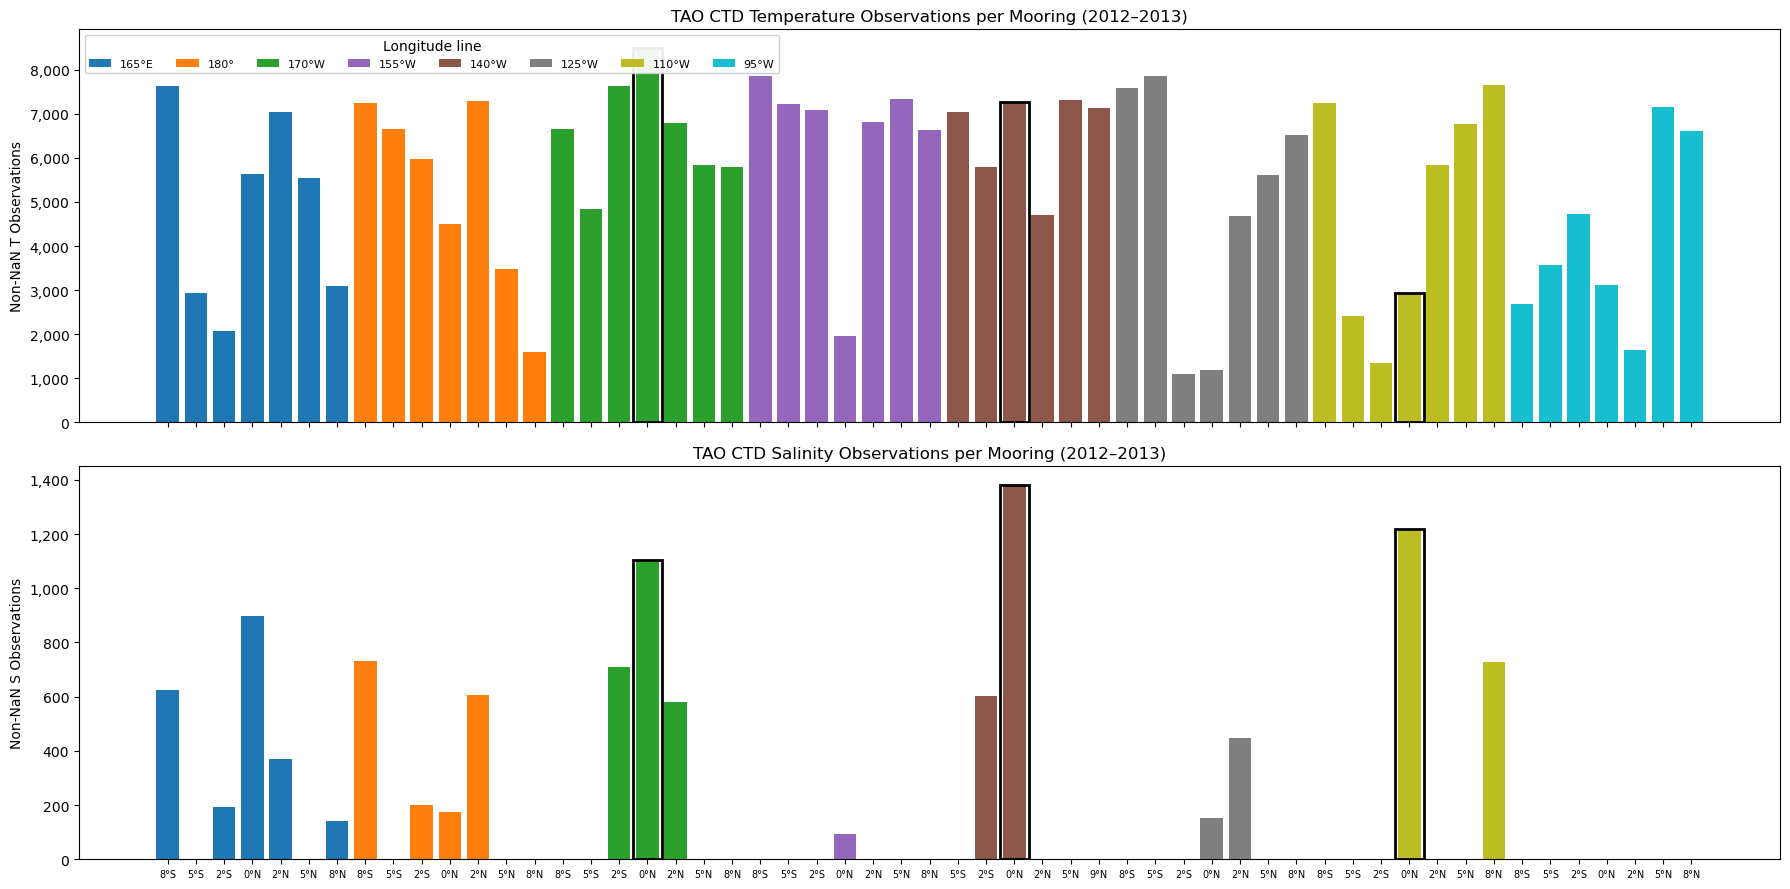

Locations: 55   Total T obs: 299,118   Total S obs: 10,955


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch, Rectangle

lons = ds_ctd['prof_lon'].values
lats = ds_ctd['prof_lat'].values
T = ds_ctd['prof_T'].values
S = ds_ctd['prof_S'].values

# Unique mooring locations sorted west-to-east then south-to-north
unique_locs = sorted(set(zip(lons, lats)), key=lambda x: (x[0], x[1]))

# Count valid observations per location (exclude -9999 fill values)
t_counts, s_counts = [], []
for lon, lat in unique_locs:
    mask = (lons == lon) & (lats == lat)
    t_counts.append(int(np.sum(T[mask] > -9000)))
    s_counts.append(int(np.sum(S[mask] > -9000)))

# Color by longitude line
unique_lons = sorted(set(loc[0] for loc in unique_locs))
cmap = cm.get_cmap('tab10', len(unique_lons))
lon_color = {lon: cmap(i) for i, lon in enumerate(unique_lons)}
bar_colors = [lon_color[loc[0]] for loc in unique_locs]

def fmt_label(lon, lat):
    ns = 'N' if lat >= 0 else 'S'
    return f"{abs(int(lat))}°{ns}"

def fmt_lon(lon):
    if lon == 180:
        return '180°'
    elif lon > 180:
        return f'{int(360 - lon)}°W'
    else:
        return f'{int(lon)}°E'

labels = [fmt_label(lon, lat) for lon, lat in unique_locs]

# Equatorial moorings to highlight: 0°N at 140°W (220°E), 170°W (190°E), 110°W (250°E)
highlight = {(220.0, 0.0), (190.0, 0.0), (250.0, 0.0)}
highlight_idx = [i for i, loc in enumerate(unique_locs)
                 if (float(loc[0]), float(loc[1])) in highlight]

x = np.arange(len(unique_locs))
bar_width = 0.8
pad = 0.12  # extra horizontal space around highlighted bars

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)

for ax, counts, ylabel, title in [
    (axes[0], t_counts, 'Non-NaN T Observations', 'TAO CTD Temperature Observations per Mooring (2012–2013)'),
    (axes[1], s_counts, 'Non-NaN S Observations', 'TAO CTD Salinity Observations per Mooring (2012–2013)'),
]:
    ax.bar(x, counts, color=bar_colors, edgecolor='none', width=bar_width)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    for idx in highlight_idx:
        h = counts[idx]
        ax.add_patch(Rectangle(
            (idx - bar_width/2 - pad, 0),
            bar_width + 2*pad, h,
            fill=False, edgecolor='black', linewidth=2, zorder=5
        ))

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=7)

legend_handles = [Patch(facecolor=lon_color[lon], label=fmt_lon(lon)) for lon in unique_lons]
axes[0].legend(handles=legend_handles, ncol=len(unique_lons), loc='upper left',
               fontsize=8, framealpha=0.93, title='Longitude line')

plt.tight_layout()
plt.show()

print(f"Locations: {len(unique_locs)}   Total T obs: {sum(t_counts):,}   Total S obs: {sum(s_counts):,}")

fig.savefig('tao_ctd_obs_counts.png', dpi=300)


In [9]:
# Write TAO mooring locations to text file
# Format: lon lat per line, grouped by longitude line (matches tpose_vel_controls.ipynb format)
# Read into Python as:
#   tao_moorings = [tuple(map(float, l.split())) for l in open(path)
#                   if not l.strip().startswith('#') and l.strip()]
outpath = '/home/edavenport/analysis/vel-assim-manuscript/tao_moorings.txt'

from collections import defaultdict
lon_groups = defaultdict(list)
for lon, lat in unique_locs:
    lon_groups[lon].append(lat)

lon_labels = {
    165.0: '165°E Line',
    180.0: '180°E Line',
    190.0: '190°E Line (170°W)',
    205.0: '205°E Line (155°W)',
    220.0: '220°E Line (140°W)',
    235.0: '235°E Line (125°W)',
    250.0: '250°E Line (110°W)',
    265.0: '265°E Line (95°W)',
}

with open(outpath, 'w') as f:
    f.write('# TAO mooring locations present in TAO_WO_2012/2013_CTD_daily_ED.nc\n')
    f.write('# Format: lon lat (degrees East, degrees North)\n')
    f.write('# Read into Python as:\n')
    f.write('#   tao_moorings = [tuple(map(float, l.split())) for l in open(path)\n')
    f.write('#                   if not l.strip().startswith(\'#\') and l.strip()]\n')
    for lon in sorted(lon_groups.keys(), reverse=True):
        label = lon_labels.get(lon, f'{int(lon)}°E Line')
        f.write(f'# {label}\n')
        for lat in sorted(lon_groups[lon], reverse=True):
            f.write(f'{lon:.1f} {lat:.1f}\n')

print(f"Wrote {len(unique_locs)} mooring locations to {outpath}")


Wrote 55 mooring locations to /home/edavenport/analysis/vel-assim-manuscript/tao_moorings.txt
